### **A-I 574 Natural Language Processing**

##### ***Initial Settings***

In [51]:
# Importing the Required Libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import time

# Use Apple Metal GPU if available
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


##### ***Loading, Exploring, and Preprocessing the Dataset***

In [52]:
# Loading the datasets
data_path = '/Users/aryamandev/Library/Mobile Documents/com~apple~CloudDocs/NLP/week3/tatoeba/'
train_df = pd.read_csv(data_path + 'sentences.top10langs.train.tsv', sep='\t', header=None)
dev_df = pd.read_csv(data_path + 'sentences.top10langs.dev.tsv', sep='\t', header=None)

# Rename columns for clarity
train_df.columns = ['lang', 'sentence']
dev_df.columns = ['lang', 'sentence']

display(train_df.head())

,lang,sentence
0,spa,"Te di mi corazón para que lo ames, ¡no para us..."
1,spa,Contamos con tu ayuda.
2,spa,Tú eres superficial y materialista.
3,spa,Los límites son para los demás.
4,spa,Todos ellos esperaron ansiosamente las vacacio...


In [53]:
# Encode Labels
label_encoder = LabelEncoder()
train_df['label'] = label_encoder.fit_transform(train_df['lang'])
dev_df['label'] = label_encoder.transform(dev_df['lang'])
num_classes = len(label_encoder.classes_)
print(f"Classes: {label_encoder.classes_}")

Classes: ['ber' 'deu' 'eng' 'epo' 'fra' 'hun' 'ita' 'por' 'spa' 'tur']


##### ***Custom PyTorch Dataset and Tokenization***

In [54]:
# Character-level vocabulary for Custom Models
chars = set("".join(train_df['sentence'].values))
vocab = {ch: i+2 for i, ch in enumerate(chars)}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1
vocab_size = len(vocab)
MAX_LEN = 128

def encode_text(text):
    return [vocab.get(ch, 1) for ch in text[:MAX_LEN]] + [0] * max(0, MAX_LEN - len(text))

class TatoebaDataset(Dataset):
    def __init__(self, df, is_hf=False, tokenizer=None):
        self.sentences = df['sentence'].values
        self.labels = df['label'].values
        self.is_hf = is_hf
        self.tokenizer = tokenizer
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        if self.is_hf:
            encoding = self.tokenizer(
                self.sentences[idx],
                max_length=MAX_LEN,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            return {
                'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'label': torch.tensor(self.labels[idx], dtype=torch.long)
            }
        else:
            encoded = encode_text(self.sentences[idx])
            return {
                'input_ids': torch.tensor(encoded, dtype=torch.long),
                'label': torch.tensor(self.labels[idx], dtype=torch.long)
            }

batch_size = 256
train_dataset = TatoebaDataset(train_df)
dev_dataset = TatoebaDataset(dev_df)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)

##### ***Reusable Functions***

In [55]:
def model_fit(model, train_loader, dev_loader, epochs=5, is_hf=False):
    model.to(device)
    lr = 0.00002 if is_hf else 0.001
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    
    best_val_acc = 0
    patience_counter = 0
    patience = 2
    
    for epoch in range(epochs):
        start = time.time()
        model.train()
        total_loss, correct, total = 0, 0, 0
        
        for i, batch in enumerate(train_loader):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            
            if is_hf:
                outputs = model(input_ids, attention_mask=batch['attention_mask'].to(device))
                logits = outputs.logits
            else:
                logits = model(input_ids)
                
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            if i % 50 == 0:
                print(f"  Step {i}/{len(train_loader)} - current loss: {total_loss/(i+1):.4f}")
            
        train_acc = correct / total
        train_loss = total_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for batch in dev_loader:
                input_ids = batch['input_ids'].to(device)
                labels = batch['label'].to(device)
                
                if is_hf:
                    outputs = model(input_ids, attention_mask=batch['attention_mask'].to(device))
                    logits = outputs.logits
                else:
                    logits = model(input_ids)
                    
                loss = criterion(logits, labels)
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                if i % 50 == 0:
                    print(f"  Step {i}/{len(train_loader)} - current loss: {total_loss/(i+1):.4f}")
                
        val_acc = val_correct / val_total
        val_loss = val_loss / len(dev_loader)
        
        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | {time.time()-start:.0f}s - loss: {train_loss:.4f} - acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
                
    model.load_state_dict(torch.load('best_model.pt'))
    return history

def plot_accuracy(history, name):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title(f"{name} - Accuracy")
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss', marker='o')
    plt.plot(history['val_loss'], label='Validation Loss', marker='o')
    plt.title(f"{name} - Loss")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, dev_loader, name, is_hf=False):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dev_loader:
            input_ids = batch['input_ids'].to(device)
            if is_hf:
                logits = model(input_ids, attention_mask=batch['attention_mask'].to(device)).logits
            else:
                logits = model(input_ids)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['label'].numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"--- {name} Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print(f"Trainable Params: {params:,}")
    return {"Model": name, "Accuracy": acc, "Macro F1": f1, "Parameters": params}

results = []

##### ***Model 1: Simple RNN***

  Step 0/391 - current loss: 2.3045
  Step 50/391 - current loss: 2.3080
  Step 100/391 - current loss: 2.3058
  Step 150/391 - current loss: 2.3055
  Step 200/391 - current loss: 2.3049
  Step 250/391 - current loss: 2.3045
  Step 300/391 - current loss: 2.3042
  Step 350/391 - current loss: 2.3040
Epoch 1/10 | 17s - loss: 2.3039 - acc: 0.1016 - val_loss: 2.3000 - val_acc: 0.1023
  Step 0/391 - current loss: 2.3001
  Step 50/391 - current loss: 2.3025
  Step 100/391 - current loss: 2.3021
  Step 150/391 - current loss: 2.3016
  Step 200/391 - current loss: 2.3015
  Step 250/391 - current loss: 2.3015
  Step 300/391 - current loss: 2.3015
  Step 350/391 - current loss: 2.3014
Epoch 2/10 | 17s - loss: 2.3014 - acc: 0.1032 - val_loss: 2.3013 - val_acc: 0.1013
  Step 0/391 - current loss: 2.2947
  Step 50/391 - current loss: 2.3006
  Step 100/391 - current loss: 2.3010
  Step 150/391 - current loss: 2.3010
  Step 200/391 - current loss: 2.3007
  Step 250/391 - current loss: 2.3006
  Step 

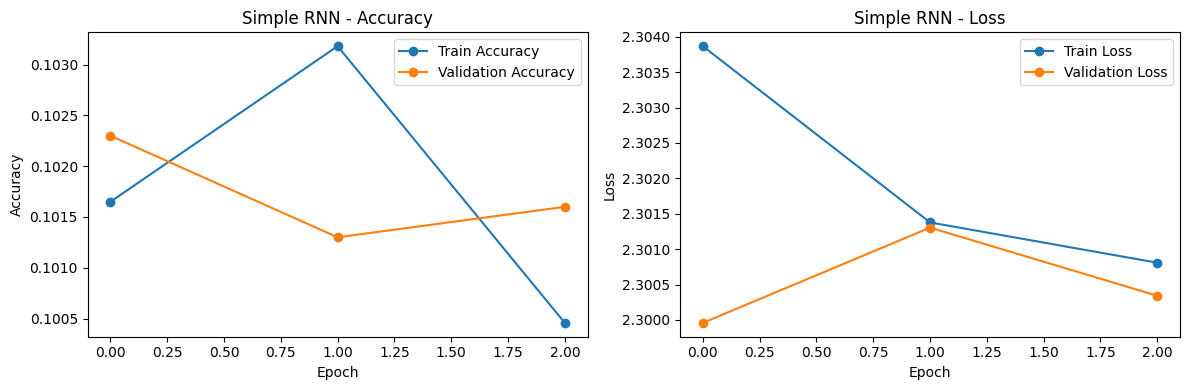

--- Simple RNN Results ---
Accuracy: 0.1023
Macro F1: 0.0241
Trainable Params: 29,642


In [56]:
class SimpleRNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.rnn = nn.RNN(32, 128, batch_first=True)
        self.fc = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

model_rnn = SimpleRNNModel()
history_rnn = model_fit(model_rnn, train_loader, dev_loader, epochs=10)
plot_accuracy(history_rnn, "Simple RNN")
results.append(evaluate_model(model_rnn, dev_loader, "Simple RNN"))

##### ***Model 2: LSTM***

  Step 0/391 - current loss: 2.3080
  Step 50/391 - current loss: 2.3060
  Step 100/391 - current loss: 2.3046
  Step 150/391 - current loss: 2.3039
  Step 200/391 - current loss: 2.3078
  Step 250/391 - current loss: 2.3072
  Step 300/391 - current loss: 2.3064
  Step 350/391 - current loss: 2.3057
Epoch 1/10 | 10s - loss: 2.3053 - acc: 0.1031 - val_loss: 2.3043 - val_acc: 0.1000
  Step 0/391 - current loss: 2.3131
  Step 50/391 - current loss: 2.2991
  Step 100/391 - current loss: 2.3002
  Step 150/391 - current loss: 2.2969
  Step 200/391 - current loss: 2.2746
  Step 250/391 - current loss: 2.2048
  Step 300/391 - current loss: 2.0959
  Step 350/391 - current loss: 1.9884
Epoch 2/10 | 10s - loss: 1.9084 - acc: 0.2359 - val_loss: 1.1853 - val_acc: 0.5013
  Step 0/391 - current loss: 1.1474
  Step 50/391 - current loss: 1.0466
  Step 100/391 - current loss: 0.9587
  Step 150/391 - current loss: 0.9066
  Step 200/391 - current loss: 0.8757
  Step 250/391 - current loss: 0.8417
  Step 

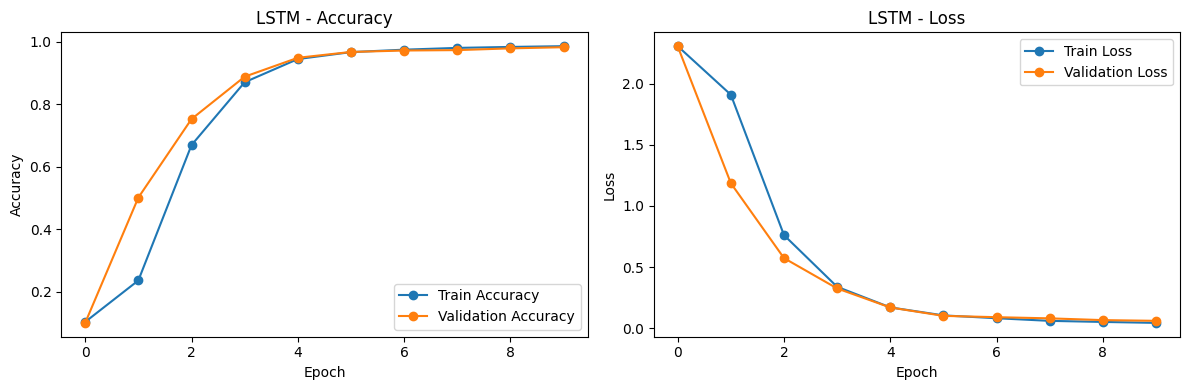

--- LSTM Results ---
Accuracy: 0.9828
Macro F1: 0.9828
Trainable Params: 91,850


In [57]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.lstm = nn.LSTM(32, 128, batch_first=True)
        self.fc = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model_lstm = LSTMModel()
history_lstm = model_fit(model_lstm, train_loader, dev_loader, epochs=10)
plot_accuracy(history_lstm, "LSTM")
results.append(evaluate_model(model_lstm, dev_loader, "LSTM"))

##### ***Model 3: BiLSTM***

  Step 0/391 - current loss: 2.3127
  Step 50/391 - current loss: 2.3049
  Step 100/391 - current loss: 2.3041
  Step 150/391 - current loss: 2.3049
  Step 200/391 - current loss: 2.3039
  Step 250/391 - current loss: 2.3032
  Step 300/391 - current loss: 2.3026
  Step 350/391 - current loss: 2.2982
Epoch 1/10 | 26s - loss: 2.2719 - acc: 0.1148 - val_loss: 1.8747 - val_acc: 0.2300
  Step 0/391 - current loss: 1.8475
  Step 50/391 - current loss: 1.8125
  Step 100/391 - current loss: 1.7522
  Step 150/391 - current loss: 1.6671
  Step 200/391 - current loss: 1.5757
  Step 250/391 - current loss: 1.4904
  Step 300/391 - current loss: 1.4072
  Step 350/391 - current loss: 1.3992
Epoch 2/10 | 26s - loss: 1.3550 - acc: 0.4410 - val_loss: 0.9134 - val_acc: 0.6449
  Step 0/391 - current loss: 0.9655
  Step 50/391 - current loss: 0.8682
  Step 100/391 - current loss: 0.8303
  Step 150/391 - current loss: 0.8012
  Step 200/391 - current loss: 0.7818
  Step 250/391 - current loss: 0.7591
  Step 

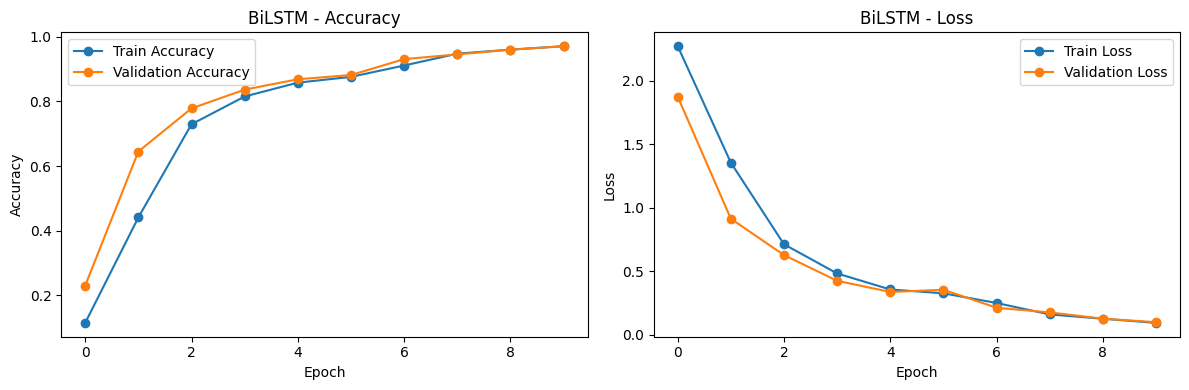

--- BiLSTM Results ---
Accuracy: 0.9705
Macro F1: 0.9705
Trainable Params: 176,074


In [58]:
class BiLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.lstm = nn.LSTM(32, 128, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model_bilstm = BiLSTMModel()
history_bilstm = model_fit(model_bilstm, train_loader, dev_loader, epochs=10)
plot_accuracy(history_bilstm, "BiLSTM")
results.append(evaluate_model(model_bilstm, dev_loader, "BiLSTM"))

##### ***Model 4: BiGRU***

  Step 0/391 - current loss: 2.3046
  Step 50/391 - current loss: 2.3068
  Step 100/391 - current loss: 2.3060
  Step 150/391 - current loss: 2.3050
  Step 200/391 - current loss: 2.3043
  Step 250/391 - current loss: 2.3014
  Step 300/391 - current loss: 2.2542
  Step 350/391 - current loss: 2.1620
Epoch 1/10 | 41s - loss: 2.0762 - acc: 0.1830 - val_loss: 1.3310 - val_acc: 0.4650
  Step 0/391 - current loss: 1.3595
  Step 50/391 - current loss: 1.0924
  Step 100/391 - current loss: 0.9751
  Step 150/391 - current loss: 0.8891
  Step 200/391 - current loss: 0.8127
  Step 250/391 - current loss: 0.7474
  Step 300/391 - current loss: 0.6906
  Step 350/391 - current loss: 0.6430
Epoch 2/10 | 37s - loss: 0.6116 - acc: 0.7711 - val_loss: 0.3263 - val_acc: 0.8887
  Step 0/391 - current loss: 0.3996
  Step 50/391 - current loss: 0.2803
  Step 100/391 - current loss: 0.2608
  Step 150/391 - current loss: 0.2470
  Step 200/391 - current loss: 0.2375
  Step 250/391 - current loss: 0.2282
  Step 

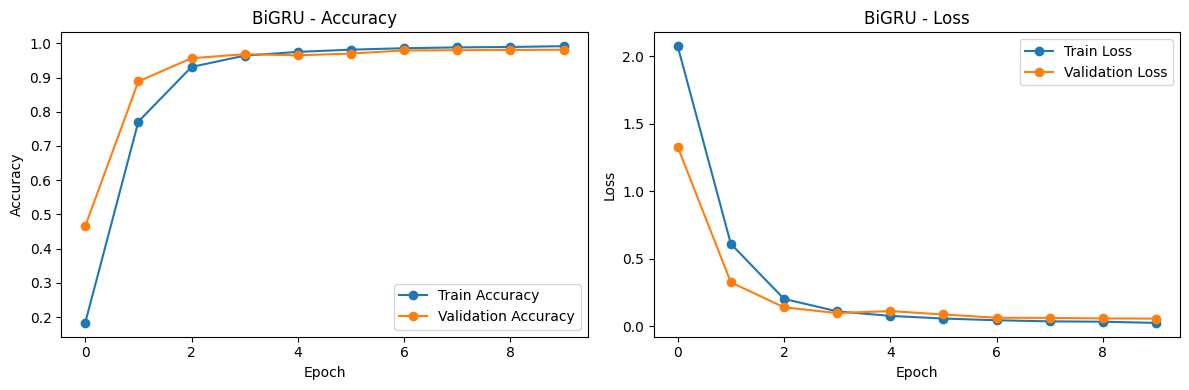

--- BiGRU Results ---
Accuracy: 0.9812
Macro F1: 0.9812
Trainable Params: 134,602


In [59]:
class BiGRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.gru = nn.GRU(32, 128, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

model_bigru = BiGRUModel()
history_bigru = model_fit(model_bigru, train_loader, dev_loader, epochs=10)
plot_accuracy(history_bigru, "BiGRU")
results.append(evaluate_model(model_bigru, dev_loader, "BiGRU"))

##### ***Model 5: Transformer Encoder***

  Step 0/391 - current loss: 2.4953
  Step 50/391 - current loss: 2.2637
  Step 100/391 - current loss: 1.9199
  Step 150/391 - current loss: 1.6183
  Step 200/391 - current loss: 1.4041
  Step 250/391 - current loss: 1.2549
  Step 300/391 - current loss: 1.1415
  Step 350/391 - current loss: 1.0508
Epoch 1/10 | 113s - loss: 0.9913 - acc: 0.6557 - val_loss: 0.4203 - val_acc: 0.8596
  Step 0/391 - current loss: 0.3347
  Step 50/391 - current loss: 0.4292
  Step 100/391 - current loss: 0.4201
  Step 150/391 - current loss: 0.4124
  Step 200/391 - current loss: 0.4074
  Step 250/391 - current loss: 0.4017
  Step 300/391 - current loss: 0.3960
  Step 350/391 - current loss: 0.3904
Epoch 2/10 | 89s - loss: 0.3870 - acc: 0.8653 - val_loss: 0.3633 - val_acc: 0.8779
  Step 0/391 - current loss: 0.3773
  Step 50/391 - current loss: 0.3490
  Step 100/391 - current loss: 0.3413
  Step 150/391 - current loss: 0.3419
  Step 200/391 - current loss: 0.3387
  Step 250/391 - current loss: 0.3367
  Step

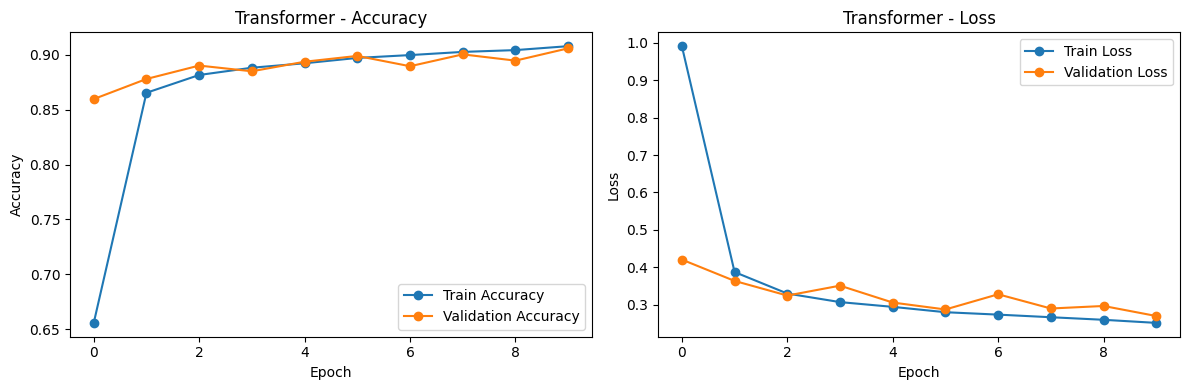

--- Transformer Results ---
Accuracy: 0.9058
Macro F1: 0.9053
Trainable Params: 282,954


In [60]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        encoder_layer = nn.TransformerEncoderLayer(d_model=32, nhead=4, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        out = self.transformer(x)
        return self.fc(out.mean(dim=1))

model_trans = TransformerModel()
history_trans = model_fit(model_trans, train_loader, dev_loader, epochs=10)
plot_accuracy(history_trans, "Transformer")
results.append(evaluate_model(model_trans, dev_loader, "Transformer"))

##### ***Model 6: Encoder-Decoder***

  Step 0/391 - current loss: 2.3179
  Step 50/391 - current loss: 2.3067
  Step 100/391 - current loss: 2.3055
  Step 150/391 - current loss: 2.3047
  Step 200/391 - current loss: 2.3038
  Step 250/391 - current loss: 2.2851
  Step 300/391 - current loss: 2.1953
  Step 350/391 - current loss: 2.0862
Epoch 1/10 | 20s - loss: 1.9943 - acc: 0.2144 - val_loss: 1.1051 - val_acc: 0.5493
  Step 0/391 - current loss: 1.0580
  Step 50/391 - current loss: 0.9487
  Step 100/391 - current loss: 0.8319
  Step 150/391 - current loss: 0.7373
  Step 200/391 - current loss: 0.6592
  Step 250/391 - current loss: 0.5977
  Step 300/391 - current loss: 0.5481
  Step 350/391 - current loss: 0.5095
Epoch 2/10 | 20s - loss: 0.4805 - acc: 0.8229 - val_loss: 0.2114 - val_acc: 0.9285
  Step 0/391 - current loss: 0.1585
  Step 50/391 - current loss: 0.1984
  Step 100/391 - current loss: 0.1923
  Step 150/391 - current loss: 0.1829
  Step 200/391 - current loss: 0.1775
  Step 250/391 - current loss: 0.1726
  Step 

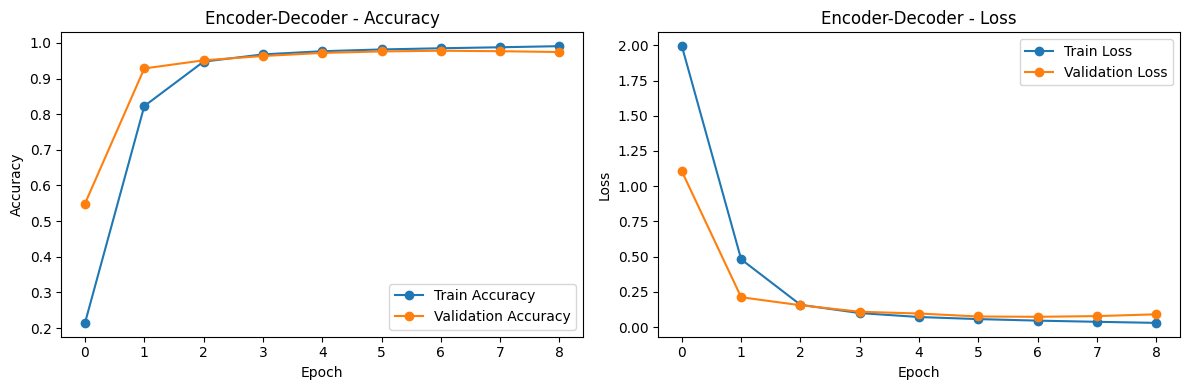

--- Encoder-Decoder Results ---
Accuracy: 0.9782
Macro F1: 0.9782
Trainable Params: 133,322


In [61]:
class EncDecModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.encoder = nn.GRU(32, 128, batch_first=True)
        self.decoder = nn.GRU(32, 128, batch_first=True)
        self.fc = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.encoder(x)
        # Dummy decoder pass using last hidden state
        decoder_input = torch.zeros(x.size(0), 1, 32).to(x.device)
        out, _ = self.decoder(decoder_input, hidden)
        return self.fc(out[:, -1, :])

model_encdec = EncDecModel()
history_encdec = model_fit(model_encdec, train_loader, dev_loader, epochs=10)
plot_accuracy(history_encdec, "Encoder-Decoder")
results.append(evaluate_model(model_encdec, dev_loader, "Encoder-Decoder"))

##### ***HuggingFace Transformer Preprocessing***

In [63]:
# Create a tiny subset for the heavy Transformer models
train_df_tiny = train_df.sample(n=5000, random_state=42)

def get_hf_loaders_tiny(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    hf_train = TatoebaDataset(train_df_tiny, is_hf=True, tokenizer=tokenizer)
    hf_dev = TatoebaDataset(dev_df, is_hf=True, tokenizer=tokenizer)
    return DataLoader(hf_train, batch_size=16, shuffle=True), DataLoader(hf_dev, batch_size=16, shuffle=False)



##### ***Final Results Summary***

In [65]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(by="Macro F1", ascending=False))

,Model,Accuracy,Macro F1,Parameters
1,LSTM,0.9828,0.982795,91850
3,BiGRU,0.9812,0.981222,134602
5,Encoder-Decoder,0.9782,0.978244,133322
2,BiLSTM,0.9705,0.970485,176074
4,Transformer,0.9058,0.905286,282954
0,Simple RNN,0.1023,0.024133,29642
